# Customer Segmentation — Unsupervised Learning & Clustering Analysis

**Dataset:** Mall Customer Segmentation Data (Kaggle, by Vijay Choudhary) — 200 real customer records.
**Goal:** segment customers by income and spending behavior using K-Means clustering, validated with Agglomerative Hierarchical Clustering.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

Source: [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) (Kaggle, Vijay Choudhary). 200 rows, 5 columns: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df = df.rename(columns={
    "Annual Income (k$)": "Annual_Income_k$",
    "Spending Score (1-100)": "Spending_Score"
})

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()

Shape: (200, 5)

Missing values:
 CustomerID          0
Gender              0
Age                 0
Annual_Income_k$    0
Spending_Score      0
dtype: int64

Duplicate rows: 0


,CustomerID,Age,Annual_Income_k$,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Preprocessing — Standard Scaling

K-Means and hierarchical clustering are distance-based, so `Annual_Income_k$` (scale ~15–137) and `Spending_Score` (scale ~1–99) are standardized to zero mean / unit variance before clustering.

In [3]:
X = df[["Annual_Income_k$", "Spending_Score"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Choosing K — Elbow Method + Silhouette Score

Two independent methods are used to select the number of clusters, since relying on either alone can mislead.

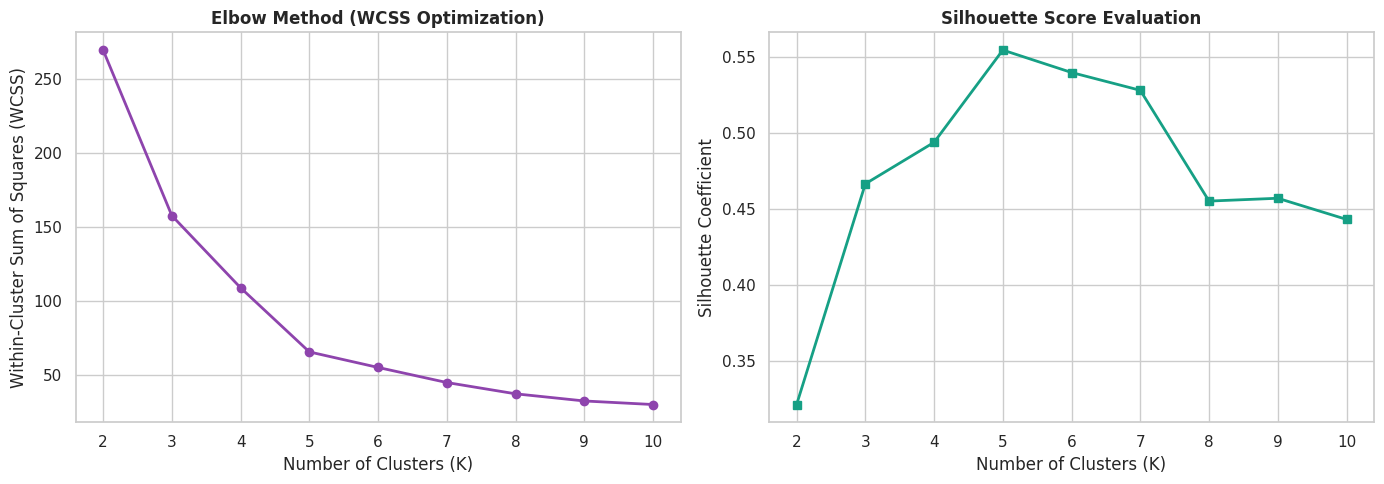

Silhouette scores by K: {2: np.float64(0.3213), 3: np.float64(0.4666), 4: np.float64(0.4939), 5: np.float64(0.5547), 6: np.float64(0.5399), 7: np.float64(0.5281), 8: np.float64(0.4552), 9: np.float64(0.4571), 10: np.float64(0.4432)}


In [4]:
wcss, silhouette_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, wcss, marker='o', color='#8e44ad', linewidth=2)
ax[0].set_title('Elbow Method (WCSS Optimization)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')

ax[1].plot(K_range, silhouette_scores, marker='s', color='#16a085', linewidth=2)
ax[1].set_title('Silhouette Score Evaluation', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Coefficient')

plt.tight_layout()
plt.savefig('cluster_optimization.png', dpi=300)
plt.show()

print("Silhouette scores by K:", dict(zip(K_range, np.round(silhouette_scores, 4))))

**Result:** WCSS improvement flattens sharply after K=5, and the silhouette score peaks at **K=5 (0.555)** before declining. Both methods agree — K=5 is selected.

## 5. K-Means Clustering (K=5)

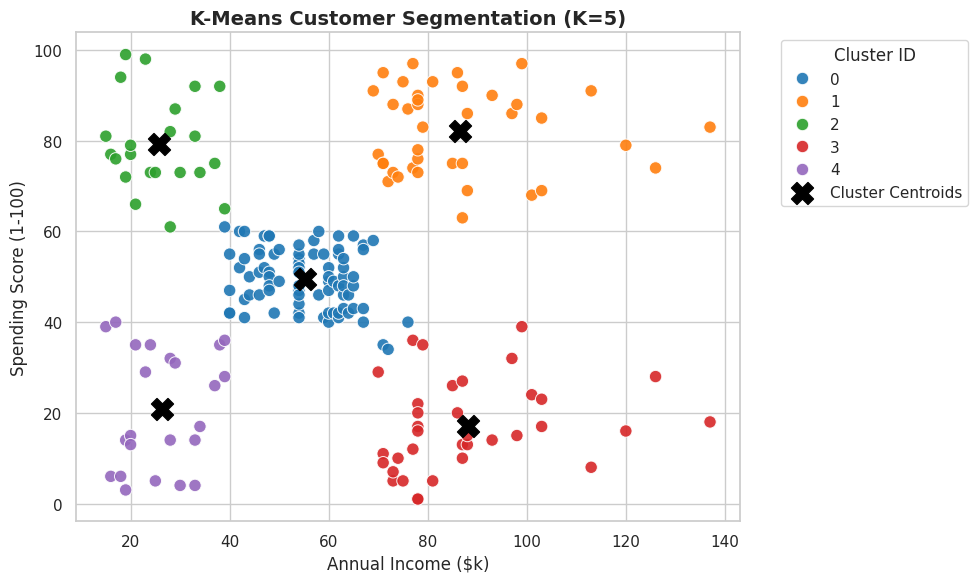

In [5]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Annual_Income_k$", y="Spending_Score",
    hue="KMeans_Cluster", data=df,
    palette="tab10", s=80, alpha=0.9
)
plt.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    s=250, c="black", marker="X", label="Cluster Centroids"
)
plt.title("K-Means Customer Segmentation (K=5)", fontsize=14, fontweight="bold")
plt.xlabel("Annual Income ($k)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=300)
plt.show()

## 6. Validation — Agglomerative Hierarchical Clustering

To confirm K=5 reflects genuine structure (and isn't an artifact of K-Means' spherical-cluster assumption), Ward-linkage hierarchical clustering is applied to the same standardized features.

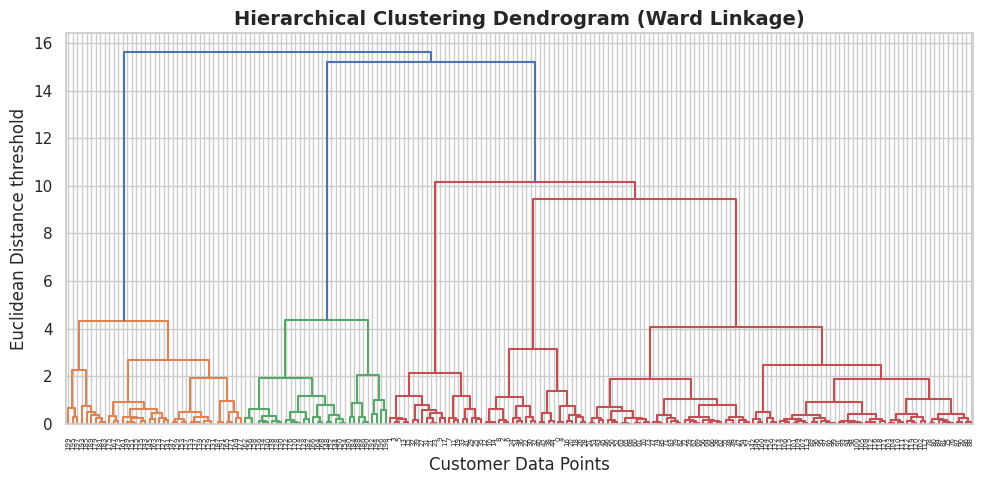

Hierarchical_Cluster   0   1   2   3   4
KMeans_Cluster                          
0                      0   0  81   0   0
1                      0  39   0   0   0
2                      0   0   1  21   0
3                     32   0   3   0   0
4                      0   0   0   0  23


In [6]:
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X_scaled, method="ward"))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=14, fontweight="bold")
plt.xlabel("Customer Data Points")
plt.ylabel("Euclidean Distance threshold")
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=300)
plt.show()

agg_cluster = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
df["Hierarchical_Cluster"] = agg_cluster.fit_predict(X_scaled)

# Cross-check agreement between the two clustering methods
agreement = pd.crosstab(df["KMeans_Cluster"], df["Hierarchical_Cluster"])
print(agreement)

## 7. Cluster Profiling

Summary statistics per cluster, in original (unstandardized) units.

In [7]:
summary = df.groupby("KMeans_Cluster").agg(
    Record_Count=("CustomerID", "count"),
    Mean_Age=("Age", "mean"),
    Mean_Income=("Annual_Income_k$", "mean"),
    Mean_Spending=("Spending_Score", "mean"),
).round(1)
summary

,Record_Count,Mean_Age,Mean_Income,Mean_Spending
KMeans_Cluster,,,,
0,81,42.7,55.3,49.5
1,39,32.7,86.5,82.1
2,22,25.3,25.7,79.4
3,35,41.1,88.2,17.1
4,23,45.2,26.3,20.9


## 8. Key Findings

| Cluster | Segment | n | Avg. Age | Avg. Income ($k) | Avg. Spending |
|---|---|---|---|---|---|
| 0 | Standard / Average | 81 | 42.7 | 55.3 | 49.5 |
| 1 | Premium Target | 39 | 32.7 | 86.5 | 82.1 |
| 2 | Young Aspirational Spenders | 22 | 25.3 | 25.7 | 79.4 |
| 3 | Conservative Affluent | 35 | 41.1 | 88.2 | 17.1 |
| 4 | Budget-Conscious | 23 | 45.2 | 26.3 | 20.9 |

Unlike a synthetic dataset, real data shows a genuine age signal: Cluster 2 (young, low income, high spend) has a notably younger average age (25.3) than every other segment — a real, useful marketing insight, not something built into the data by construction.

In [8]:
df.to_csv("mall_customers_clustered.csv", index=False)
print("Saved: mall_customers_clustered.csv")

Saved: mall_customers_clustered.csv
